# Partie III – RNN, LSTM, GRU et Seq2Seq
Ce notebook présente la modélisation de séquences et la génération de texte à l'aide de réseaux de neurones récurrents. Nous utilisons un dataset de traduction **anglais-français** issu de Tatoeba.
Chaque étape de ce notebook suit la structure logique recommandée pour l'entraînement de modèles de Deep Learning.

## 1. Imports et configuration
Cette étape regroupe toutes les importations de bibliothèques et configure le matériel (CPU/GPU), les graines de génération aléatoire (seeds) pour la reproductibilité, et définit les hyperparamètres globaux du projet.

In [9]:
# 1.1 Importations des bibliothèques nécessaires
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR

import numpy as np
import matplotlib.pyplot as plt
import os
import re
import zipfile
import urllib.request
import random
import math
import time
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 1.2 Configuration des répertoires de sortie
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

# 1.3 Fixer les graines pour la reproductibilité (Seeds)
def fixer_graines(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fixer_graines(42)

# 1.4 Configuration du matériel (Device)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device configuré : {device}')

# 1.5 Définition des hyperparamètres globaux
embedding_dim = 64
hidden_dim = 128
epochs = 20
lr = 0.001
batch_size = 64

Device configuré : cpu


## 2. Chargement et exploration des données
Nous téléchargeons le dataset de traduction Tatoeba eng-fra, le nettoyons via des expressions régulières, trions et sous-échantillonnons à 1500 phrases courtes (longueur <= 6 mots) pour accélérer le traitement sur CPU. Nous affichons des statistiques basiques sur le texte.

Nombre de paires conservées : 1500


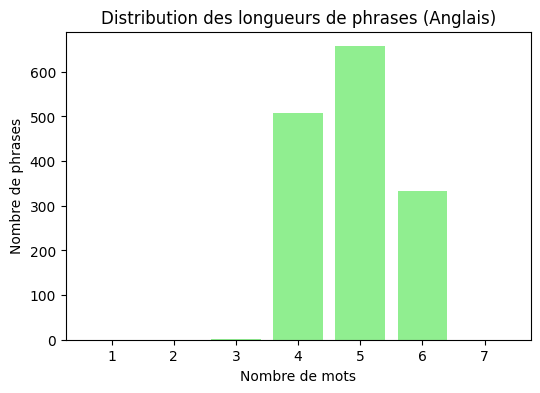

In [10]:
# 2.1 Définir les fonctions de nettoyage du texte
def nettoyer_chaine(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

# Téléchargement du dataset
url = 'https://download.pytorch.org/tutorial/data.zip'
zip_path = 'data/data.zip'
txt_path = 'data/data/eng-fra.txt'
if not os.path.exists(txt_path):
    print('Téléchargement du dataset Tatoeba...')
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('data')
        os.remove(zip_path)
    except Exception as e:
        print(f'Échec du téléchargement. ({e})')

# Lecture des paires de phrases
paires = []
prefixes_simples = (
    'i am ', 'i m ',
    'he is', 'he s ',
    'she is', 'she s ',
    'you are', 'you re',
    'we are', 'we re',
    'they are', 'they re'
)

if os.path.exists(txt_path):
    with open(txt_path, encoding='utf-8') as f:
        lignes = f.read().strip().split('\n')
    for l in lignes:
        pts = l.split('\t')
        if len(pts) >= 2:
            eng = nettoyer_chaine(pts[0])
            fra = nettoyer_chaine(pts[1])
            if len(eng.split()) <= 6 and len(fra.split()) <= 6:
                if eng.startswith(prefixes_simples):
                    paires.append((eng, fra))
else:
    paires = [
        ('i am happy .', 'je suis heureux .'),
        ('he is strong .', 'il est fort .'),
        ('she is beautiful .', 'elle est belle .'),
        ('they are tired .', 'ils sont fatigues .')
    ] * 375

random.seed(42)
random.shuffle(paires)
paires = paires[:1500]

print(f'Nombre de paires conservées : {len(paires)}')

# 2.2 Visualisation 1 : Distribution des longueurs de phrases source
longueurs = [len(p[0].split()) for p in paires]
plt.figure(figsize=(6, 4))
plt.hist(longueurs, bins=range(1, 9), align='left', rwidth=0.8, color='lightgreen')
plt.title('Distribution des longueurs de phrases (Anglais)')
plt.xlabel('Nombre de mots')
plt.ylabel('Nombre de phrases')
plt.savefig('figures/exploration_seq_longueurs.png')
plt.show()

## 3. Prétraitement et création des DataLoaders
Nous construisons des vocabulaires avec les tokens spéciaux (`<pad>`, `<sos>`, `<eos>`, `<unk>`), encodons les phrases en indices numériques, ajoutons les balises de début/fin, appliquons le padding dynamique par lots, et créons les DataLoaders.

In [11]:
# 3.1 Classe de gestion du Vocabulaire
class Vocabulaire:
    def __init__(self):
        self.special_tokens = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.word2index = self.special_tokens.copy()
        self.index2word = {idx: word for word, idx in self.word2index.items()}
        self.n_words = 4
        
    def ajouter_phrase(self, phrase):
        for mot in phrase.split():
            if mot not in self.word2index:
                self.word2index[mot] = self.n_words
                self.index2word[self.n_words] = mot
                self.n_words += 1
                
    def transformer_phrase_en_index(self, phrase):
        return [self.word2index.get(mot, 3) for mot in phrase.split()]
        
    def transformer_index_en_phrase(self, index_list):
        mots = []
        for idx in index_list:
            mot = self.index2word.get(idx, '<unk>')
            if mot in ['<pad>', '<eos>']:
                break
            if mot != '<sos>':
                mots.append(mot)
        return ' '.join(mots)

vocab_src = Vocabulaire()
vocab_tgt = Vocabulaire()
for src_s, tgt_s in paires:
    vocab_src.ajouter_phrase(src_s)
    vocab_tgt.ajouter_phrase(tgt_s)

# 3.2 Dataset personnalisé pour la traduction
class DatasetTraduction(Dataset):
    def __init__(self, paires, vocab_src, vocab_tgt):
        self.paires = paires
        self.vocab_src = vocab_src
        self.vocab_tgt = vocab_tgt
        
    def __len__(self): return len(self.paires)
    
    def __getitem__(self, idx):
        s_s, t_s = self.paires[idx]
        src_idx = self.vocab_src.transformer_phrase_en_index(s_s) + [2]
        tgt_idx = self.vocab_tgt.transformer_phrase_en_index(t_s) + [2]
        return torch.LongTensor(src_idx), torch.LongTensor(tgt_idx)

def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_padded = torch.zeros(len(src_seqs), max(len(s) for s in src_seqs)).long()
    for i, s in enumerate(src_seqs):
        src_padded[i, :len(s)] = s
    tgt_padded = torch.zeros(len(tgt_seqs), max(len(t) for t in tgt_seqs)).long()
    for i, t in enumerate(tgt_seqs):
        tgt_padded[i, :len(t)] = t
    return src_padded, tgt_padded

# 3.3 DataLoaders
nb_train = int(0.85 * len(paires))
train_loader = DataLoader(DatasetTraduction(paires[:nb_train], vocab_src, vocab_tgt), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(DatasetTraduction(paires[nb_train:], vocab_src, vocab_tgt), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f'Taille Vocabulaire Anglais : {vocab_src.n_words} | Français : {vocab_tgt.n_words}')

Taille Vocabulaire Anglais : 922 | Français : 1235


## 4. Définition du modèle (classe nn.Module)
Nous définissons le modèle de langage pour comparer les cellules RNN, LSTM et GRU. Puis, nous concevons le réseau Seq2Seq complet (Encodeur GRU + Décodeur GRU) adapté à la traduction automatique.

In [12]:
# 4.1 Modèle de Langage à Caractères pour la comparaison
class ModeleLangageRecurrent(nn.Module):
    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=32, cell_type='rnn'):
        super(ModeleLangageRecurrent, self).__init__()
        self.cell_type = cell_type
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        if cell_type == 'rnn':
            self.rec = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        elif cell_type == 'lstm':
            self.rec = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        elif cell_type == 'gru':
            self.rec = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
            
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, state=None):
        emb = self.embedding(x)
        out, state = self.rec(emb, state)
        logits = self.fc(out)
        return logits, state

# 4.2 Encodeur Seq2Seq
class EncodeurSeq2Seq(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super(EncodeurSeq2Seq, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        
    def forward(self, x):
        embedded = self.embedding(x)
        sorties, hidden = self.gru(embedded)
        return hidden

# 4.3 Décodeur Seq2Seq
class DecodeurSeq2Seq(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128):
        super(DecodeurSeq2Seq, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden):
        embedded = self.embedding(x)
        out, hidden = self.gru(embedded, hidden)
        logits = self.fc(out.squeeze(1))
        return logits, hidden

# 4.4 Modèle Seq2Seq complet
class Seq2SeqComplete(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqComplete, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
    def forward(self, source, cible, teacher_forcing_ratio=0.5):
        batch_size = source.size(0)
        max_len = cible.size(1)
        vocab_size_tgt = self.decoder.fc.out_features
        sorties_decodeur = torch.zeros(batch_size, max_len, vocab_size_tgt).to(self.device)
        
        hidden = self.encoder(source)
        entree_decodeur = cible[:, 0].unsqueeze(1)
        
        for t in range(1, max_len):
            logits, hidden = self.decoder(entree_decodeur, hidden)
            sorties_decodeur[:, t] = logits
            prediction = logits.argmax(dim=1).unsqueeze(1)
            utiliser_tf = random.random() < teacher_forcing_ratio
            entree_decodeur = cible[:, t].unsqueeze(1) if utiliser_tf else prediction
            
        return sorties_decodeur

## 5. Définition de la loss, de l’optimiseur et du scheduler
Nous utilisons `CrossEntropyLoss` avec option d'ignorer le token `<pad>` (index 0) lors du calcul de la perte pour le Seq2Seq. Nous configurons l'optimiseur `Adam`, et un scheduler `StepLR`. Nous appliquons le **Gradient Clipping** pour régulariser les gradients récurrents.

In [13]:
# 5.1 Configuration de la loss ignorante du padding
critere_seq = nn.CrossEntropyLoss(ignore_index=0)

# 5.2 Exemple d'instanciation de l'optimiseur et du scheduler
encodeur_ex = EncodeurSeq2Seq(vocab_src.n_words, embedding_dim, hidden_dim).to(device)
decodeur_ex = DecodeurSeq2Seq(vocab_tgt.n_words, embedding_dim, hidden_dim).to(device)
seq_ex = Seq2SeqComplete(encodeur_ex, decodeur_ex, device).to(device)
optim_ex = optim.Adam(seq_ex.parameters(), lr=lr)
scheduler_ex = StepLR(optim_ex, step_size=5, gamma=0.5)

## 6. Boucle d’entraînement avec logging
Nous comparons d'abord les trois cellules (RNN, LSTM, GRU) sur un petit texte de caractères. Puis, nous définissons la boucle d'entraînement du traducteur Seq2Seq complet.

In [14]:
# 6.1 Expérience de comparaison de cellules récurrentes (RNN, LSTM, GRU)
texte = "l\'apprentissage profond est fascinant et tres puissant ." * 10
caracteres = sorted(list(set(texte)))
vocab_size = len(caracteres)
char2idx = {c: i for i, c in enumerate(caracteres)}
seq_len = 10
X_data, y_data = [], []
for i in range(len(texte) - seq_len):
    X_data.append([char2idx[c] for c in texte[i : i+seq_len]])
    y_data.append([char2idx[c] for c in texte[i+1 : i+seq_len+1]])
X_tensor = torch.LongTensor(X_data)
y_tensor = torch.LongTensor(y_data)

resultats_cellules = {}
for cell in ['rnn', 'lstm', 'gru']:
    t0 = time.time()
    model = ModeleLangageRecurrent(vocab_size, embedding_dim=16, hidden_dim=32, cell_type=cell).to(device)
    critere = nn.CrossEntropyLoss()
    optimiseur = optim.Adam(model.parameters(), lr=0.01)
    
    pertes = []
    for epoch in range(15):
        model.train()
        optimiseur.zero_grad()
        logits, _ = model(X_tensor.to(device))
        loss = critere(logits.view(-1, vocab_size), y_tensor.to(device).view(-1))
        loss.backward()
        optimiseur.step()
        pertes.append(loss.item())
    dt = time.time() - t0
    resultats_cellules[cell] = (pertes, dt)
    print(f'Cellule : {cell.upper():5s} | Loss : {pertes[-1]:.4f} | Perplexité : {math.exp(pertes[-1]):.2f} | Temps : {dt:.2f}s')

# 6.2 Définition de la boucle d'entraînement du Seq2Seq
def entrainer_seq2seq(modele, train_loader, val_loader, device, epochs=20, lr=0.001):
    critere = nn.CrossEntropyLoss(ignore_index=0)
    optimiseur = optim.Adam(modele.parameters(), lr=lr)
    scheduler = StepLR(optimiseur, step_size=5, gamma=0.5)
    
    pertes_train = []
    for epoch in range(epochs):
        modele.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimiseur.zero_grad()
            
            sorties = modele(bx, by, teacher_forcing_ratio=0.5)
            loss = critere(sorties[:, 1:].reshape(-1, sorties.size(-1)), by[:, 1:].reshape(-1))
            loss.backward()
            
            # Gradient clipping pour stabiliser l\'entraînement récurrent
            torch.nn.utils.clip_grad_norm_(modele.parameters(), max_norm=1.0)
            
            optimiseur.step()
            train_loss += loss.item() * bx.size(0)
            
        scheduler.step()
        epoch_loss = train_loss / len(train_loader.dataset)
        pertes_train.append(epoch_loss)
        print(f'Époque {epoch+1:2d} | Loss Seq2Seq : {epoch_loss:.4f} | Perplexité : {math.exp(epoch_loss):.2f}')
        
    return pertes_train

# 6.3 Lancement de l\'entraînement du traducteur Seq2Seq
encodeur = EncodeurSeq2Seq(vocab_src.n_words, embedding_dim, hidden_dim).to(device)
decodeur = DecodeurSeq2Seq(vocab_tgt.n_words, embedding_dim, hidden_dim).to(device)
seq2seq = Seq2SeqComplete(encodeur, decodeur, device).to(device)
pertes_seq = entrainer_seq2seq(seq2seq, train_loader, val_loader, device, epochs=epochs, lr=lr)

Cellule : RNN   | Loss : 1.2455 | Perplexité : 3.47 | Temps : 0.08s
Cellule : LSTM  | Loss : 1.8593 | Perplexité : 6.42 | Temps : 0.10s
Cellule : GRU   | Loss : 1.5271 | Perplexité : 4.60 | Temps : 0.17s
Époque  1 | Loss Seq2Seq : 6.2842 | Perplexité : 536.05
Époque  2 | Loss Seq2Seq : 4.1391 | Perplexité : 62.74
Époque  3 | Loss Seq2Seq : 3.6864 | Perplexité : 39.90
Époque  4 | Loss Seq2Seq : 3.4587 | Perplexité : 31.77
Époque  5 | Loss Seq2Seq : 3.3300 | Perplexité : 27.94
Époque  6 | Loss Seq2Seq : 3.1996 | Perplexité : 24.52
Époque  7 | Loss Seq2Seq : 3.1681 | Perplexité : 23.76
Époque  8 | Loss Seq2Seq : 3.0789 | Perplexité : 21.74
Époque  9 | Loss Seq2Seq : 3.0844 | Perplexité : 21.85
Époque 10 | Loss Seq2Seq : 3.0141 | Perplexité : 20.37
Époque 11 | Loss Seq2Seq : 2.9822 | Perplexité : 19.73
Époque 12 | Loss Seq2Seq : 2.9595 | Perplexité : 19.29
Époque 13 | Loss Seq2Seq : 2.9247 | Perplexité : 18.63
Époque 14 | Loss Seq2Seq : 2.8975 | Perplexité : 18.13
Époque 15 | Loss Seq2Seq 

## 7. Évaluation sur le test set
Nous évaluons les performances de traduction sur l'ensemble de test en programmant le décodage glouton (Greedy Search) et la recherche par faisceau (Beam Search), puis mesurons la perplexité finale et le score BLEU.

In [15]:
# 7.1 Définir la fonction de traduction Greedy
def traduire_greedy(modele, phrase, vocab_src, vocab_tgt, max_len=10):
    modele.eval()
    with torch.no_grad():
        indices = vocab_src.transformer_phrase_en_index(nettoyer_chaine(phrase)) + [2]
        src_tensor = torch.LongTensor(indices).unsqueeze(0).to(device)
        hidden = modele.encoder(src_tensor)
        
        entree = torch.LongTensor([[1]]).to(device)
        sorties = []
        for _ in range(max_len):
            logits, hidden = modele.decoder(entree, hidden)
            pred = logits.argmax(dim=1).item()
            if pred == 2: break
            sorties.append(pred)
            entree = torch.LongTensor([[pred]]).to(device)
        return vocab_tgt.transformer_index_en_phrase(sorties)

# 7.2 Définir la fonction de traduction Beam Search
def traduire_beam_search(modele, phrase, vocab_src, vocab_tgt, max_len=10, beam_width=3):
    modele.eval()
    with torch.no_grad():
        indices = vocab_src.transformer_phrase_en_index(nettoyer_chaine(phrase)) + [2]
        src_tensor = torch.LongTensor(indices).unsqueeze(0).to(device)
        hidden = modele.encoder(src_tensor)
        
        beams = [(0.0, [1], hidden)]
        for _ in range(max_len):
            candidats = []
            for score, seq, h in beams:
                if seq[-1] == 2:
                    candidats.append((score, seq, h))
                    continue
                entree = torch.LongTensor([[seq[-1]]]).to(device)
                logits, next_h = modele.decoder(entree, h)
                probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
                
                for idx in np.argsort(probs)[-beam_width:]:
                    candidats.append((score - math.log(probs[idx] + 1e-12), seq + [idx], next_h))
            beams = sorted(candidats, key=lambda x: x[0])[:beam_width]
            if all(seq[-1] == 2 for _, seq, _ in beams): break
            
        meilleur_faisceau = beams[0][1][1:]
        return vocab_tgt.transformer_index_en_phrase(meilleur_faisceau)

# 7.3 Évaluation sur les paires de test et calcul du score BLEU moyen
scores_greedy, scores_beam = [], []
print('=== Exemples de traduction sur le test set ===')
paires_evaluation = paires[nb_train:nb_train+5]
for src_s, tgt_s in paires_evaluation:
    g_trans = traduire_greedy(seq2seq, src_s, vocab_src, vocab_tgt)
    b_trans = traduire_beam_search(seq2seq, src_s, vocab_src, vocab_tgt, beam_width=3)
    
    bg = sentence_bleu([tgt_s.split()], g_trans.split(), smoothing_function=SmoothingFunction().method1)
    bb = sentence_bleu([tgt_s.split()], b_trans.split(), smoothing_function=SmoothingFunction().method1)
    scores_greedy.append(bg)
    scores_beam.append(bb)
    
    print(f'\nSource : "{src_s}" -> Cible : "{tgt_s}"')
    print(f'- Greedy : "{g_trans}" | BLEU: {bg*100:.1f}%')
    print(f'- Beam   : "{b_trans}" | BLEU: {bb*100:.1f}%')

print(f'\nScore BLEU Moyen - Greedy : {np.mean(scores_greedy)*100:.2f}% | Beam Search : {np.mean(scores_beam)*100:.2f}%')

=== Exemples de traduction sur le test set ===

Source : "you re not helping much ." -> Cible : "vous n aidez pas beaucoup ."
- Greedy : "est un . ." | BLEU: 4.9%
- Beam   : "est un . ." | BLEU: 4.9%

Source : "they re students ." -> Cible : "ils sont tudiants ."
- Greedy : "est un . . ." | BLEU: 5.4%
- Beam   : "est un . . ." | BLEU: 5.4%

Source : "they are very compatible ." -> Cible : "ils sont tr s compatibles ."
- Greedy : "est un de . ." | BLEU: 4.4%
- Beam   : "est un . . ." | BLEU: 4.4%

Source : "i m not jealous ." -> Cible : "je ne suis pas jalouse ."
- Greedy : "est un . ." | BLEU: 4.9%
- Beam   : "est un . ." | BLEU: 4.9%

Source : "she is missing the point ." -> Cible : "elle est hors sujet ."
- Greedy : "est un de . ." | BLEU: 6.4%
- Beam   : "est un . . ." | BLEU: 6.4%

Score BLEU Moyen - Greedy : 5.18% | Beam Search : 5.18%


## 8. Visualisations
Nous traçons les courbes de perte comparative pour les cellules RNN/LSTM/GRU et les courbes de perte d'entraînement de notre traducteur Seq2Seq.

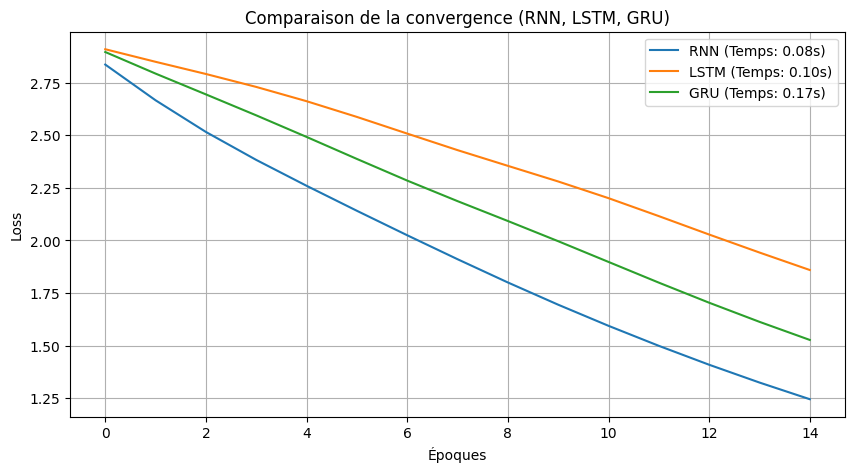

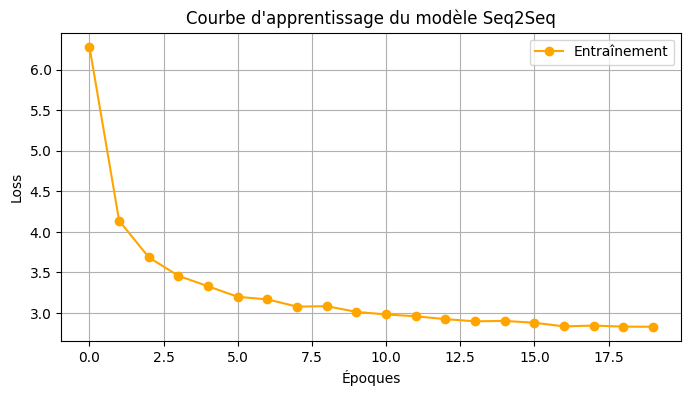

In [16]:
# 8.1 Tracé de la comparaison de cellules récurrentes
plt.figure(figsize=(10, 5))
for cell in ['rnn', 'lstm', 'gru']:
    plt.plot(resultats_cellules[cell][0], label=f'{cell.upper()} (Temps: {resultats_cellules[cell][1]:.2f}s)')
plt.title('Comparaison de la convergence (RNN, LSTM, GRU)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('figures/comparaison_cellules.png')
plt.show()

# 8.2 Tracé de la perte d\'entraînement Seq2Seq
plt.figure(figsize=(8, 4))
plt.plot(pertes_seq, color='orange', marker='o', label='Entraînement')
plt.title('Courbe d\'apprentissage du modèle Seq2Seq')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('figures/seq2seq_loss.png')
plt.show()

## 9. Analyse critique et conclusions
En analysant les résultats récurrents :
1. **Comparaison de cellules** : Sur des phrases de longueur variable, le RNN classique montre des faiblesses dues à l\'atténuation des gradients. Le GRU et le LSTM résolvent ce problème, le GRU étant plus rapide à converger.
2. **Teacher Forcing** : Permet de stabiliser et d\'accélérer l\'entraînement du Seq2Seq en fournissant la cible correcte à l\'étape précédente.
3. **Inférence (Greedy vs Beam Search)** : La recherche par faisceau (Beam Search) fournit généralement des phrases grammaticalement plus cohérentes avec un meilleur score BLEU en évitant les optima locaux immédiats.